In [6]:
import torch
import torchvision
from torch import nn
import sklearn
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [7]:
epochs = 15
learning_rate = 0.0005
batch_size = 32
if torch.accelerator.is_available():
    print(torch.accelerator.current_accelerator())
    print("Using above accelerator")
    device = torch.device(torch.accelerator.current_accelerator())
    #print(device)
else:
    print("Using CPU")
    device = torch.device("cpu")
    #print(device)

cuda
Using above accelerator


In [8]:
class BaseModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()
        self.h1 = nn.Linear(784, 16)
        #Input flattened to a 784 tensor and converted from 784 to 16 dimensions

        #Left branch code here
        self.lh1 = nn.Linear(16, 8)
        self.lh2 = nn.Linear(8, 8)
        #We save both after lh1 and lh2 and add them for skip later

        #Right branch code here
        self.rh1 = nn.Linear(16, 12)
        self.rh2 = nn.Linear(12, 8)

        self.op = nn.Linear(16, 10)

        self.ReLU = nn.ReLU()
        self.concat = torch.concat

    """Not yet using sequential, as I want to manually practise layers one by one first"""

    def forward(self, x):
        x = self.flatten(x)

        x = self.h1(x)
        x = self.ReLU(x)

        xl = self.lh1(x)
        xl = self.ReLU(xl)
        xb1 = xl
        xl = self.lh2(xl)
        xl = self.ReLU(xl)
        xl = xl + xb1
        xl = self.ReLU(xl)

        xr = self.rh1(x)
        xr = self.ReLU(xr)
        xr = self.rh2(xr)
        xr = self.ReLU(xr)

        x = self.concat([xl, xr], dim=1)
        x = self.ReLU(x)
        x = self.op(x)
        return x

In [9]:
fmnist = torchvision.datasets.FashionMNIST(
    root="data",
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

accuracy = []
lossfn = nn.CrossEntropyLoss()

fold = 1
for train, test in sklearn.model_selection.KFold(n_splits=5, random_state=67, shuffle=True).split(fmnist):
    model = BaseModel()
    model.to(device)
    optim = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.0001)
    trainsampler = torch.utils.data.sampler.SubsetRandomSampler(train)
    testsampler = torch.utils.data.sampler.SubsetRandomSampler(test)
    trainloader = torch.utils.data.DataLoader(fmnist, sampler=trainsampler, batch_size=batch_size)
    testloader = torch.utils.data.DataLoader(fmnist, sampler=testsampler, batch_size=batch_size)
    val_lossl = []
    train_accl = []
    val_accl = []
    actual_val_loss = []
    for epoch in range(epochs):
        epoch += 1
        model.train()
        loss = 0.0
        correct = 0
        total = 0
        for x, y in trainloader:
            x = x.to(device)
            y = y.to(device)
            optim.zero_grad()
            outputs = model(x)
            losst = lossfn(outputs, y)
            losst.backward()
            optim.step()
            loss = loss + losst.item()
            pred = torch.max(outputs, 1)[1]
            pred = pred==y
            correct += pred.sum().item()
            total += y.size(0)
        model.eval()
        with torch.no_grad():
            correct_eval = 0
            total_eval = 0
            val_loss = 0.0
            for x, y in testloader:
                x = x.to(device)
                y = y.to(device)
                outputs = model(x)
                batch_loss = lossfn(outputs, y)
                val_loss += batch_loss.item()
                pred = torch.max(outputs, 1)[1]
                pred = pred == y
                correct_eval += pred.sum().item()
                total_eval += y.size(0)
        avg_val_loss = val_loss / len(testloader)
        actual_val_loss.append(avg_val_loss)
        val_lossl.append(loss/len(trainloader))
        train_accl.append(correct/total*100)
        val_accl.append(correct_eval/total_eval*100)
        print("Fold ", fold, ", Epoch ", epoch, " | ", sep = "", end = "")
        print("Validation Accuracy: ", correct_eval / total_eval * 100, end = "")
        print(" Training Accuracy: ", correct / total * 100, end = "")
        print(" Loss: ", loss/len(trainloader))
        if epoch == epochs:
            fold += 1
            accuracy.append(correct_eval / total_eval * 100)

print("Final average accuracy:", sum(accuracy) / len(accuracy))

Fold 1, Epoch 1 | Validation Accuracy:  80.75833333333333 Training Accuracy:  69.95208333333333 Loss:  0.8421516971985499
Fold 1, Epoch 2 | Validation Accuracy:  82.65 Training Accuracy:  81.99375 Loss:  0.5096689793169499
Fold 1, Epoch 3 | Validation Accuracy:  83.36666666666666 Training Accuracy:  83.86666666666667 Loss:  0.46290546532471977
Fold 1, Epoch 4 | Validation Accuracy:  84.84166666666667 Training Accuracy:  84.73125 Loss:  0.4377248444855213
Fold 1, Epoch 5 | Validation Accuracy:  84.63333333333334 Training Accuracy:  85.19166666666666 Loss:  0.41938313088317714
Fold 1, Epoch 6 | Validation Accuracy:  84.925 Training Accuracy:  85.675 Loss:  0.40547716183960436
Fold 1, Epoch 7 | Validation Accuracy:  85.75833333333334 Training Accuracy:  86.08958333333334 Loss:  0.393552813226978
Fold 1, Epoch 8 | Validation Accuracy:  85.80833333333334 Training Accuracy:  86.4 Loss:  0.38528332093854745
Fold 1, Epoch 9 | Validation Accuracy:  86.14166666666667 Training Accuracy:  86.7 Los

Final Validation Loss: 0.3916


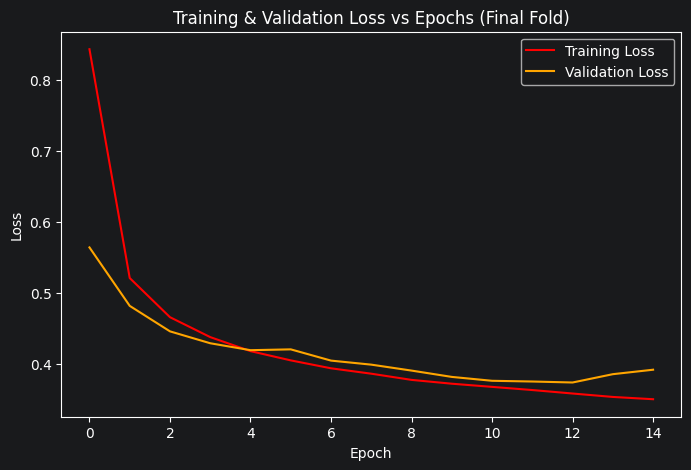

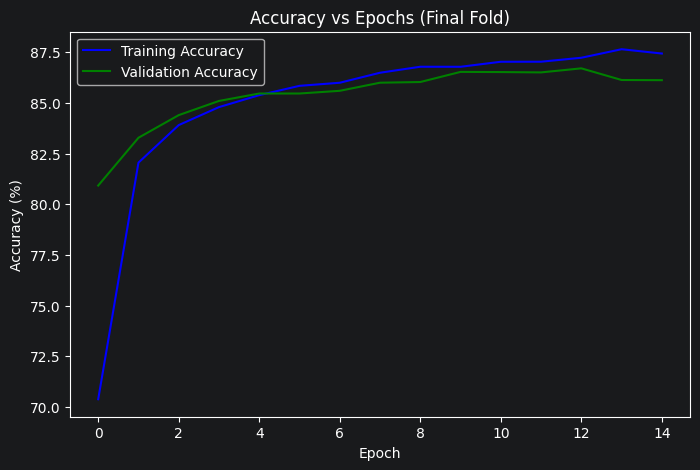

Generating submissions.csv
submission.csv saved successfully!
model_weights.pkl saved successfully!


In [12]:
print(f"Final Validation Loss: {actual_val_loss[-1]:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(val_lossl, label="Training Loss", color='red')
plt.plot(actual_val_loss, label="Validation Loss", color='orange')

plt.title("Training & Validation Loss vs Epochs (Final Fold)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss_curve.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accl, label="Training Accuracy", color='blue')
plt.plot(val_accl, label="Validation Accuracy", color='green')
plt.title("Accuracy vs Epochs (Final Fold)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.savefig("accuracy_curve.png")
plt.show()

print("Generating submissions.csv")

test_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)
final_test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size)

final_predictions = []
model.eval()
with torch.no_grad():
    for x, _ in final_test_loader:
        x = x.to(device)
        outputs = model(x)
        pred = torch.max(outputs, 1)[1]
        final_predictions.extend(pred.cpu().numpy().tolist())

df = pd.DataFrame({
    "Id": range(len(final_predictions)),
    "Label": final_predictions
})
df.to_csv("submission.csv", index=False)
print("submission.csv saved successfully!")

weights = model.state_dict()
pickle.dump(weights, open("model_weights.pkl", "wb"))
print("model_weights.pkl saved successfully!")